# 03 — The Multi-Agent Investigation Graph

This is where the pieces become a system. The graph below investigates one AML
case end-to-end: triage → forensic investigation → risk assessment → report →
**human approval gate** → audit trail.

```mermaid
flowchart TD
    START([START]) --> T[triage<br/><i>structured LLM</i>]
    T --> I[investigate<br/><i>ReAct agent + forensic tools</i>]
    I --> C[coverage_net<br/><b>deterministic</b>: runs skipped checks]
    C --> R[assess_risk<br/><i>structured LLM + guardrail floor</i>]
    R -->|needs more evidence, max 1| G[gather_more] --> R
    R --> W[write_report<br/><i>free-text LLM</i>]
    W --> V[validate<br/><b>deterministic</b>: structure, citations,<br/>numeric groundedness]
    V -->|invalid, retry| W
    V -->|invalid, budget spent| F[fallback_report<br/><b>deterministic</b> Jinja template]
    V -->|valid| H[human_gate<br/>interrupt ⏸]
    F --> H
    H --> Z[finalize<br/>report file + case_log row] --> END([END])
```

**The reliability thesis of this design:** every LLM step is paired with a
deterministic safety mechanism — the agent *proposes*, the machinery *guarantees*:

| LLM step | what guarantees correctness anyway |
|---|---|
| triage picks checks | `coverage_net` diff-and-runs anything mandated but skipped |
| ReAct investigation | tools are deterministic; evidence persisted server-side |
| risk scoring | OFAC-match guardrail floor; validated schema with fallback |
| report writing | validator (citations + every $ figure re-checked) → template fallback |

So a flaky 8B model can degrade *quality*, but it cannot crash the pipeline,
skip a sanctions screen, or fabricate an evidence number that survives validation.

In [1]:
import json
import sqlite3

import pandas as pd
from IPython.display import Image, Markdown, display
from langgraph.checkpoint.sqlite import SqliteSaver  # file-backed state snapshots
from langgraph.types import Command                  # used to resume after an interrupt()

from aml_investigator import db, telemetry
from aml_investigator.graph.build import build_graph
from aml_investigator.settings import settings

con = db.connect()  # the warehouse the forensic tools query

# The checkpointer is what makes the graph pausable and resumable. We build it over a
# LONG-LIVED sqlite3 connection (check_same_thread=False) rather than the usual
# `with SqliteSaver.from_conn_string(...)` context-manager form — that form closes the
# DB at the end of the cell, which fights Jupyter's cell-by-cell execution. (This is a
# real gotcha; it's documented in the project README and CLAUDE.md.)
settings.checkpoint_db_path.parent.mkdir(parents=True, exist_ok=True)
ckpt_conn = sqlite3.connect(settings.checkpoint_db_path, check_same_thread=False)
checkpointer = SqliteSaver(ckpt_conn)   # durable: survives kernel/process restarts
graph = build_graph(con, checkpointer=checkpointer)  # compiles the StateGraph above

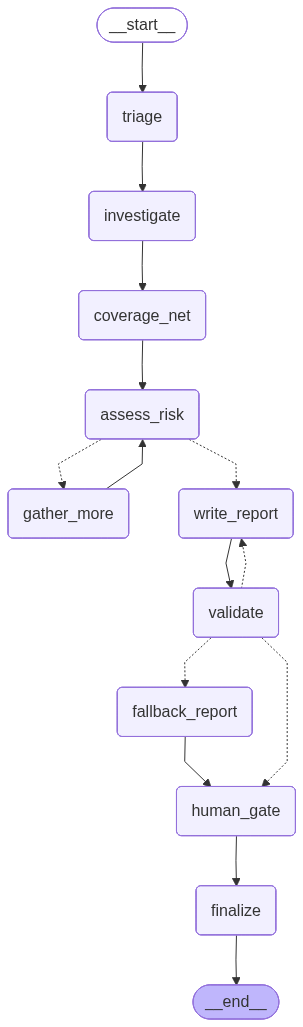

In [2]:
# Render the actual compiled topology (not just the diagram above)
try:
    png = graph.get_graph().draw_mermaid_png()
    (settings.artifacts_dir / "graph.png").write_bytes(png)
    display(Image(png, width=420))
except Exception as e:   # offline fallback: print the mermaid source
    print(f"(mermaid render unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## Case 1 — a structuring alert, streamed node by node

`stream_mode="updates"` shows each node finishing in real time. The run pauses
at the human gate (`__interrupt__`).

In [3]:
# Pick a known structuring account (ids are looked up at runtime, never hardcoded —
# regenerating the warehouse reshuffles them) and pull its real rule alerts.
account = con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'structuring' LIMIT 1").fetchone()[0]
alerts = [{"rule": r, "details": d} for r, d in con.execute(
    "SELECT rule, details FROM alerts WHERE account_id = ?", [account]).fetchall()]
case_id = f"NB03-{account}"
con.execute("DELETE FROM evidence WHERE case_id = ?", [case_id])   # idempotent re-runs
con.execute("DELETE FROM case_log WHERE case_id = ?", [case_id])
# thread_id is the case's durable identity in the checkpointer — one thread per case.
config = {"configurable": {"thread_id": case_id}}

print(f"Investigating {account}, alerts: {[a['rule'] for a in alerts]}\n")
with telemetry.case_scope(case_id) as tel:
    for update in graph.stream(
        {"case_id": case_id, "account_id": account, "alerts": alerts},
        config, stream_mode="updates",
    ):
        for node, payload in update.items():
            if node == "__interrupt__":
                print("⏸  INTERRUPTED at human_gate — waiting for a human decision")
            else:
                keys = list(payload or {})
                print(f"✔ {node:<16} -> updated {keys}")

Investigating ACC-0046, alerts: ['sub_threshold_deposits', 'large_high_risk_wire']



✔ triage           -> updated ['triage', 'reflection_rounds', 'report_retries']


✔ investigate      -> updated ['investigator_summary', 'checks_completed']
✔ coverage_net     -> updated ['coverage_ran', 'checks_completed']


2026-06-12 19:03:32.510 | WARNING  | aml_investigator.llm:structured_llm_call:92 - assess_risk: failed (OutputParserException: model returned no structured payload
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/), escalating


✔ assess_risk      -> updated ['risk']


2026-06-12 19:03:49.755 | WARNING  | aml_investigator.graph.build:validate:223 - report validation failed: ['Dollar figure $10 does not appear in any stored evidence — remove it or replace it with a figure from the evidence']


✔ write_report     -> updated ['report_md']
✔ validate         -> updated ['report_errors', 'report_retries']


2026-06-12 19:04:00.863 | WARNING  | aml_investigator.graph.build:validate:223 - report validation failed: ['Dollar figure $10 does not appear in any stored evidence — remove it or replace it with a figure from the evidence']


✔ write_report     -> updated ['report_md']
✔ validate         -> updated ['report_errors', 'report_retries']
✔ fallback_report  -> updated ['report_md', 'used_fallback_report', 'report_errors']
⏸  INTERRUPTED at human_gate — waiting for a human decision


In [4]:
# What is the graph waiting on? Inspect the live checkpoint.
snapshot = graph.get_state(config)
print("next node:", snapshot.next)
interrupt_payload = snapshot.interrupts[0].value
print("risk score:", interrupt_payload["risk"]["risk_score"],
      "| typology:", interrupt_payload["risk"]["typology"],
      "| recommendation:", interrupt_payload["risk"]["recommendation"])

next node: ('human_gate',)
risk score: 75 | typology: structuring | recommendation: ESCALATE


In [5]:
# The compliance officer approves. Command(resume=...) re-enters the graph
# exactly where it paused.
with telemetry.case_scope(case_id) as tel2:
    state = graph.invoke(Command(resume={"decision": "approve"}), config)
print("final disposition:", state["final_disposition"])
print("report written to:", state["report_path"])

final disposition: ESCALATE
report written to: /home/ahmad/AI/Projects/agentic-aml-investigator/artifacts/reports/NB03-ACC-0046.md


In [6]:
display(Markdown(state["report_md"]))

## Case Summary
Automated investigation of account ACC-0046 (case NB03-ACC-0046).
Alert(s): sub_threshold_deposits: R1: 12 cash deposits in the $8.5k-$10k band within the period; large_high_risk_wire: R3: 1 outbound wires >= $8k to high-risk countries (PA). The drafted narrative failed validation 2 time(s),
so this report was rendered deterministically from the validated evidence and the
structured risk assessment.

## Evidence
- [EV-01] (profile_account) ACC-0046 (personal, 'Vanessa Patel', CA, opened 2025-05-05): total in $136,059 / out $127,031, 139 counterparties across 2 countries, active on 67 days. Top flows: in cash_deposit n=12 $112,447; out wire n=1 $108,539; in salary n=3 $23,612; out card n=130 $13,270
- [EV-02] (structuring_scan) ACC-0046: 12 cash deposits in the $8,500-$10,000 band totalling $112,447 between 2026-04-16 and 2026-04-21 (max 2/day); 0 deposits >= $10,000 ($0).
- [EV-03] (counterparty_network) ACC-0046: 3 distinct senders, 136 distinct receivers. Top counterparties: out Christopher Clark (PA) $108,539; in Martinez PLC (US) $7,871; in Smith, Alexander and Carter (US) $7,871; in Hobbs, Gonzalez and Shaw (US) $7,871. CIRCULAR RING(S) DETECTED: [{'ring': ['ACC-0046', 'ACC-0165', 'ACC-0093'], 'total_transferred': 1385.0}, {'ring': ['ACC-0046', 'ACC-0091', 'ACC-0056'], 'total_transferred': 2314.0}]
- [EV-04] (sanctions_check) ACC-0046: screened 139 counterparty names against 19,065 OFAC SDN entries (fuzzy cutoff 87). No matches.

## Risk Assessment
Risk score: 75/100. Best-matching typology: structuring.
- Multiple sub‑threshold cash deposits just under $10k [[EV-02]]
- Large outbound wire to a high‑risk jurisdiction (PA) [[EV-03]]
- Presence of circular transfer rings involving the account [[EV-03]]

## Recommendation
Based on the structured assessment above, the recommended action is ESCALATE.

DISPOSITION: ESCALATE

Every dollar figure in that report was validated against the evidence store before
the human ever saw it (notebook 02's validator) — and the case is now in the audit
trail:

In [7]:
con.execute("SELECT * FROM case_log WHERE case_id = ?", [case_id]).fetch_df()

,case_id,account_id,final_disposition,risk_score,typology,human_decision,report_path,closed_at
0,NB03-ACC-0046,ACC-0046,ESCALATE,75,structuring,approve,/home/ahmad/AI/Projects/agentic-aml-investigat...,2026-06-12 19:04:00.887664


## Kill-and-resume: the persistence demo that matters

Investigations pause for human review — in production that can be *days*, and the
process will restart in between. Because the checkpointer is SQLite-backed, we can
**throw away every Python object, rebuild from the file, and resume the paused
case**. (Restarting the notebook kernel here would prove the same thing; rebuilding
the objects is the same code path and keeps the notebook executable top-to-bottom.)

In [8]:
account2 = con.execute(
    "SELECT account_id FROM ground_truth WHERE typology = 'sanctioned_counterparty' LIMIT 1"
).fetchone()[0]
alerts2 = [{"rule": "manual_referral", "details": "Periodic KYC review"}]
case_id2 = f"NB03-{account2}"
con.execute("DELETE FROM evidence WHERE case_id = ?", [case_id2])
con.execute("DELETE FROM case_log WHERE case_id = ?", [case_id2])
config2 = {"configurable": {"thread_id": case_id2}}

with telemetry.case_scope(case_id2):
    graph.invoke({"case_id": case_id2, "account_id": account2, "alerts": alerts2}, config2)
print("paused at:", graph.get_state(config2).next)

# --- simulate process death ---
del graph, checkpointer
ckpt_conn.close()
print("…graph object destroyed, sqlite connection closed…")

2026-06-12 19:04:11.912 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: counterparty_network


2026-06-12 19:04:11.949 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: sanctions_check


2026-06-12 19:04:13.481 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: structuring_scan


2026-06-12 19:04:13.488 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: velocity_scan


2026-06-12 19:04:35.874 | WARNING  | aml_investigator.graph.build:validate:223 - report validation failed: ['Dollar figure $42,070 does not appear in any stored evidence — remove it or replace it with a figure from the evidence', 'Dollar figure $73,279, does not appear in any stored evidence — remove it or replace it with a figure from the evidence']


2026-06-12 19:04:52.572 | WARNING  | aml_investigator.graph.build:validate:223 - report validation failed: ['Dollar figure $42,070 does not appear in any stored evidence — remove it or replace it with a figure from the evidence', 'Dollar figure $78,277, does not appear in any stored evidence — remove it or replace it with a figure from the evidence']


paused at: ('human_gate',)
…graph object destroyed, sqlite connection closed…


In [9]:
# A 'new process': fresh connection, fresh saver, fresh compiled graph
ckpt_conn = sqlite3.connect(settings.checkpoint_db_path, check_same_thread=False)
checkpointer = SqliteSaver(ckpt_conn)
graph = build_graph(con, checkpointer=checkpointer)

restored = graph.get_state(config2)
print("restored from disk — next node:", restored.next)
print("pending risk score:", restored.interrupts[0].value["risk"]["risk_score"])

restored from disk — next node: ('human_gate',)
pending risk score: 80


In [10]:
# Resume the restored case as if days had passed and a different process picked it up.
with telemetry.case_scope(case_id2):
    state2 = graph.invoke(Command(resume={"decision": "approve"}), config2)
print("disposition:", state2["final_disposition"],
      "| risk:", state2["risk"]["risk_score"], state2["risk"]["typology"])
for f in state2["risk"]["factors"][:4]:
    print(" -", f["claim"][:110], f"[{f['evidence_id']}]")

disposition: ESCALATE | risk: 80 sanctioned_counterparty
 - Two counterparties match OFAC SDN entries with high fuzzy scores (Islamic Armu Of Aden and Haqqaui, Nasiruddin [[EV-03]]
 - Outbound transactions to the matched counterparties total $73,279, indicating potential illicit linkage. [[EV-02]]
 - Velocity scan shows a burst on 2026-04-17 with 11 transactions ($16,700), exceeding baseline activity by ~2x. [[EV-05]]


### Time travel: the full checkpoint history

Every super-step was snapshotted. `get_state_history` is the audit trail of the
*computation* (the `case_log` table is the audit trail of the *decision*):

In [11]:
history = list(graph.get_state_history(config2))
pd.DataFrame([{
    "step": s.metadata.get("step"),
    "node": next(iter(s.metadata.get("writes") or {"-": None})),
    "has_interrupt": bool(s.interrupts),
} for s in history]).head(12)

,step,node,has_interrupt
0,21,-,False
1,20,-,False
2,19,-,True
3,18,-,False
4,17,-,False
5,16,-,False
6,15,-,False
7,14,-,False
8,13,-,False
9,12,-,False


## Case 3 — a hard negative (alert fired, account is clean)

The rules flagged this cash-intensive business for sub-threshold deposits.
A good investigator should notice deposits *above* the threshold too (structurers
never go over), the months-long stable pattern, and clear sanctions screening —
and dismiss.

In [12]:
hard_neg = con.execute("""
    SELECT a.account_id FROM alerts a
    LEFT JOIN ground_truth g USING (account_id)
    JOIN accounts acc ON acc.account_id = a.account_id
    WHERE g.account_id IS NULL AND a.rule = 'sub_threshold_deposits'
    ORDER BY a.account_id LIMIT 1""").fetchone()[0]
alerts3 = [{"rule": r, "details": d} for r, d in con.execute(
    "SELECT rule, details FROM alerts WHERE account_id = ?", [hard_neg]).fetchall()]
case_id3 = f"NB03-{hard_neg}"
con.execute("DELETE FROM evidence WHERE case_id = ?", [case_id3])
con.execute("DELETE FROM case_log WHERE case_id = ?", [case_id3])
config3 = {"configurable": {"thread_id": case_id3}}

with telemetry.case_scope(case_id3) as tel3:
    graph.invoke({"case_id": case_id3, "account_id": hard_neg, "alerts": alerts3}, config3)
    # This time the human OVERRIDES rather than approving — the gate has teeth:
    # whatever the system recommended, the officer records DISMISS with a note.
    state3 = graph.invoke(Command(resume={
        "decision": "override", "disposition": "DISMISS",
        "note": "Verified legitimate cash-intensive business; deposits exceed the "
                "threshold routinely, pattern stable for months."}), config3)
print("system recommended:", state3["risk"]["recommendation"],
      f"(score {state3['risk']['risk_score']})")
print("officer recorded:  ", state3["final_disposition"], "(human override)")
print("\nrisk factors the system cited:")
for f in state3["risk"]["factors"]:
    print(" -", f["claim"][:110], f"[{f['evidence_id']}]")

2026-06-12 19:05:14.073 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: profile_account


2026-06-12 19:05:14.089 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: sanctions_check


2026-06-12 19:05:16.772 | INFO     | aml_investigator.graph.build:coverage_net:136 - coverage net running skipped check: structuring_scan


2026-06-12 19:05:32.951 | WARNING  | aml_investigator.graph.build:validate:223 - report validation failed: ['Dollar figure $8.5 does not appear in any stored evidence — remove it or replace it with a figure from the evidence']


system recommended: ESCALATE (score 65)
officer recorded:   DISMISS (human override)

risk factors the system cited:
 - The account exhibits classic structuring behavior with multiple sub‑threshold cash deposits just under $10,000 [[EV-03]]
 - 22 of the total 182 cash deposits fall within the $8,500–$10,000 range, indicating an attempt to avoid CTR rep [[EV-03]]
 - No counterparties are associated with these sub‑threshold deposits, suggesting internal movement or layering. [[EV-04]]


Whether the model dismisses this case is a *quality* question — notebook 04
measures it across all 18 labeled cases instead of anecdotes. Telemetry for this
case, as a preview of what the eval aggregates:

In [13]:
tel3.summary()

{'case_id': 'NB03-ACC-0001',
 'llm_calls': 10,
 'llm_seconds': 49.5,
 'prompt_tokens': 11261,
 'completion_tokens': 1512,
 'tool_calls': 10,
 'tool_errors': 3,
 'structured_retries': 0,
 'structured_fallbacks': 0}

In [14]:
ckpt_conn.close()
con.close()